## Ornish

The dataset comes from the publication of the MEvA-X tool for biomarker discovery. It contains microarry gene expression, with information of Age, Gender, COPD, Diabetes, and WeightLoss, making 13524 features on 89 samples. The WeightLoss information was transformed into a binary variable: Responders for those with a weight loss higher than 10%, and Non_responders otherwise. The objective is to investigate the relationship between weight loss and gene expression profiles. See more information at *MEvA-X: a hybrid multiobjective evolutionary tool using an XGBoost classifier for biomarkers discovery on biomedical datasets* (https://doi.org/10.1093/bioinformatics/btad384 and https://github.com/PanKonstantinos/MEvA-X).

In [1]:
import pandas as pd
import xgboost as xgb
import os
import multiprocessing
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt
import seaborn as sns
#import urllib.request

/Users/subasrees/Desktop/anaconda3/envs/intermediateML_2024/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
inputFile = '/Users/subasrees/Desktop/intermediate-machine-learning-training/data/Ornish.csv'
df = pd.read_csv(inputFile, index_col=0)
df.dropna(axis=0, inplace=True)
print(df.shape)
print(df.head())

(89, 13520)
                A1CF       A2M    A4GALT     A4GNT      AAAS      AACS  \
GSM1123226  1.997137  2.927813  3.379954  3.118075  4.511405  4.087969   
GSM1123229  1.977951  2.815217  3.554587  3.421110  3.975408  3.698030   
GSM1123232  2.000448  2.699377  3.859986  3.109845  4.412049  3.750196   
GSM1123235  2.163751  2.597491  3.735692  3.248038  4.336756  3.884665   
GSM1123238  2.264534  2.766004  3.839986  3.389460  4.405672  3.635781   

               AADAC     AAGAB      AAK1     AAMDC  ...      ZXDB      ZXDC  \
GSM1123226  2.214993  4.288835  3.572398  3.250973  ...  2.020370  5.075711   
GSM1123229  2.135038  4.303349  3.600630  3.562200  ...  2.151221  4.695243   
GSM1123232  1.999807  4.254621  3.444927  3.533278  ...  2.090296  4.818034   
GSM1123235  2.133586  3.978215  3.238115  3.383351  ...  2.000901  4.682398   
GSM1123238  2.041702  4.077370  3.724022  3.518026  ...  2.227170  4.376936   

                 ZYX     ZZEF1      ZZZ3       Age  Sex  COPD  Diabe

In this dataset, weight loss information transformed into a binary label: participants with a weight loss higher than a selected threshold equal to 10% were considered to belong in the positive class (Responders), whereas participants with lower weight loss or even increased weight were considered to belong in the negative class (Non_responders).

Let's keep the `WeightLoss` apart as reponse and convert to numeric (0,1) values.

In [3]:
X = df.drop(columns=['WeightLoss'])
Y = df['WeightLoss']
mapping = {'Non_responders': 0, 'Responders':1}
inv_mapping = {v: k for k, v in mapping.items()}
Y = Y.map(mapping)
print(X.shape)
print(Y.value_counts())

(89, 13519)
WeightLoss
1    54
0    35
Name: count, dtype: int64


Investigate distribution of gene expression

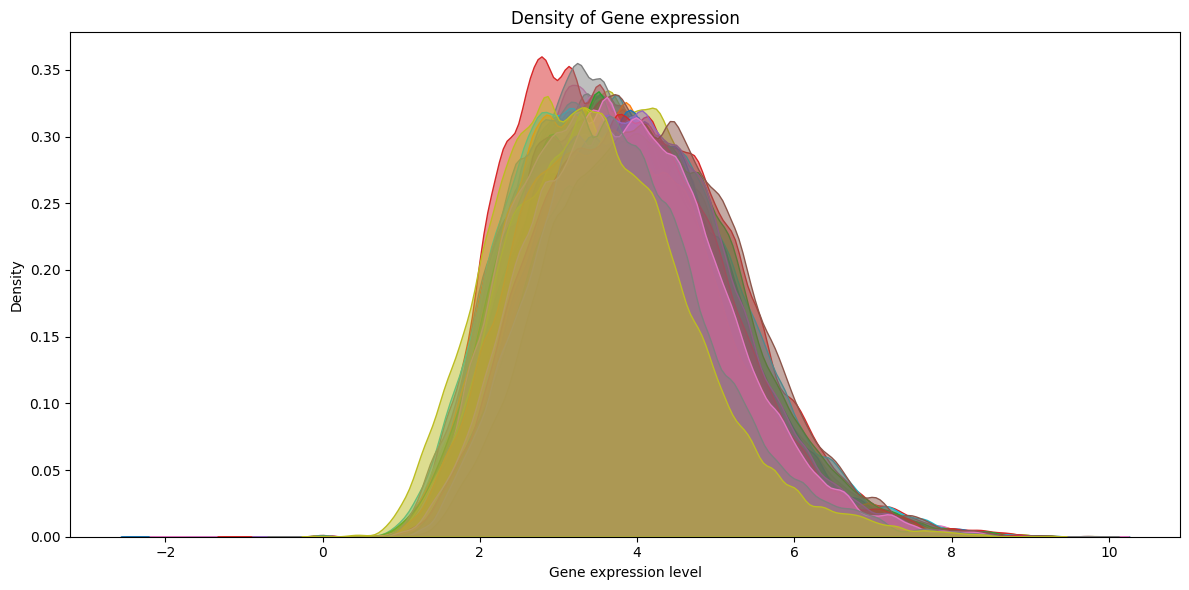

In [4]:
plt.figure(figsize=(12, 6))

# plot density for each sample
for i in range(X.shape[0]):
    sns.kdeplot(X.iloc[i,:], bw_adjust=0.5, fill=True, alpha=0.5)

plt.title('Density of Gene expression')
plt.xlabel('Gene expression level')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

Perform PCA on gene expression data and visualize with the response or certain features on different components.

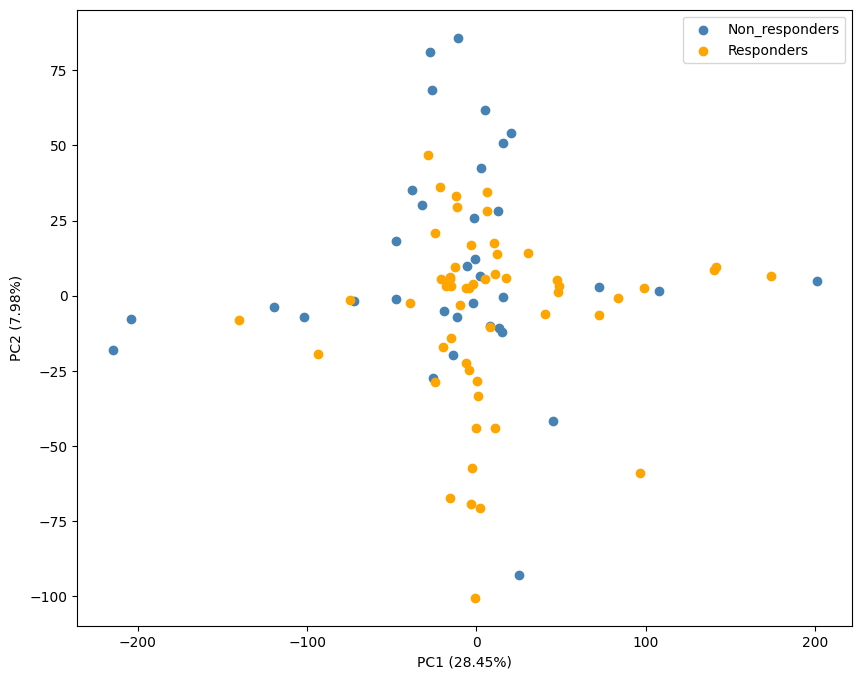

In [5]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.colors as mcolors

# standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# scatter plot of the first two principal components
plt.figure(figsize=(10, 8))

labels = Y
plt.scatter(X_pca[labels==0, 0], X_pca[labels==0, 1], color='steelblue', label=inv_mapping[0])
plt.scatter(X_pca[labels==1, 0], X_pca[labels==1, 1], color='orange', label=inv_mapping[1])
plt.legend()

plt.xlabel('PC1 ({:.2f}%)'.format(pca.explained_variance_ratio_[0] * 100))
plt.ylabel('PC2 ({:.2f}%)'.format(pca.explained_variance_ratio_[1] * 100))

plt.show()

The goal of this project is to find gene biomarker for the weight loss response. There are 13514 genes in the data, thus applying XGBoost and SHAP directly can be tricky due to the curse of dimensionality. Certain approaches could be considered, for instance, i) use unsupervised feature selection with principal components, ii) supervised filtering to keep top genes most correlated with the response (`SelectKBest`), iii) modules of coregulated genes.

import pandas as pd

# Assuming X is your DataFrame of features
corr_matrix = X.corr().abs()  # absolute value of correlation

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
print("Features to drop due to high correlation:", to_drop)
X_reduced = X.drop(columns=to_drop)

In [6]:
from sklearn.datasets import load_digits
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Scale to [0,1] → chi2 happy
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled)


In [7]:
# splitting traing and test, along with a validation set from training set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, test_size=0.2, stratify=Y, random_state=42
)

In [8]:
# Your SelectKBest step
selector = SelectKBest(chi2, k=2000)
X_train_new = selector.fit_transform(X_train, y_train)
X_test_new = selector.transform(X_test)

# Now selector exists
mask = selector.get_support()
selected_features = X.columns[mask]
print("Selected CpGs:", selected_features[:10])


Selected CpGs: Index(['AAAS', 'ABCA12', 'ABCA4', 'ABCB1.1', 'ABCB1.2', 'ABCB6', 'ABCB9',
       'ABCD1', 'ABCG2', 'ABHD14A'],
      dtype='object')


In [9]:
## load all necessary libraries from scikit
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    roc_curve, auc as sklearn_auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,f1_score,RocCurveDisplay
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
#from catboost import CatBoostClassifier
import os


In [10]:
# confusion matrix 
def plot_confmat(y_true, y_pred, title="Confusion matrix",savepath=None):
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    ax = disp.plot(values_format="d").ax_
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)
    ax.set_title(title)
    plt.xticks(rotation=30,ha='right',fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()

    # SAVE
    if savepath is not None:
        os.makedirs(savepath, exist_ok=True)
        fname = title.replace(" ", "_").lower()
        plt.savefig(
        os.path.join(savepath, f"{fname}.pdf"),
        dpi=300,
        bbox_inches="tight")
        os.makedirs(savepath, exist_ok=True)
        fname = title.replace(" ", "_").lower()
        plt.savefig(
        os.path.join(savepath, f"{fname}.jpg"),
        dpi=300,
        bbox_inches="tight")
        plt.show()


In [29]:
# AUC-ROC curves
def plot_roc_if_binary(model, X_test, y_test, title="ROC",savepath=None):
    classes = np.unique(y_test)
    if len(classes) != 2:
        return
    # prob for positive class (classes[1])
    #y_prob = model.predict(X_test)
    #auc = roc_auc_score(y_test, y_prob)

    # Probabilities for ROC/PR
    proba = model.predict(X_test)
    pred  = (proba >= 0.5).astype(int)

    print(classification_report(y_test, pred, digits=3))
    # PR
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = sklearn_auc(fpr, tpr)
    #RocCurveDisplay.from_predictions(y_test, y_prob)
    #plt.title(f"{title} (AUC={auc:.3f})")
    plt.figure(figsize=(4,4))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    # SAVE
    if savepath is not None:
        os.makedirs(savepath, exist_ok=True)
        fname = title.replace(" ", "_").lower()
        plt.savefig(
            os.path.join(savepath, f"{fname}.pdf"),
            dpi=300,
            bbox_inches="tight")
        plt.savefig(
            os.path.join(savepath, f"{fname}.jpg"),
            dpi=300,
            bbox_inches="tight")
        plt.show()
        plt.close()



In [12]:
pipe=  Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("clf", XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        ))
])

In [13]:
# do imputing and scaling of data
preprocess = [
    ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("scaler", StandardScaler())]

In [14]:
param_grids = {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [4, 6],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8],
        "clf__colsample_bytree": [0.8]
}

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_pipe = pipe
grid = param_grids
gs = GridSearchCV(
        base_pipe,
        param_grid=grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1)
gs.fit(X_train_new, y_train)

print("Best CV macro-F1:", round(gs.best_score_, 3))
print("Best params:", gs.best_params_)

Best CV macro-F1: 0.639
Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 400, 'clf__subsample': 0.8}



XGB TEST macro-F1 = 0.625
              precision    recall  f1-score   support

           0      0.600     0.429     0.500         7
           1      0.692     0.818     0.750        11

    accuracy                          0.667        18
   macro avg      0.646     0.623     0.625        18
weighted avg      0.656     0.667     0.653        18



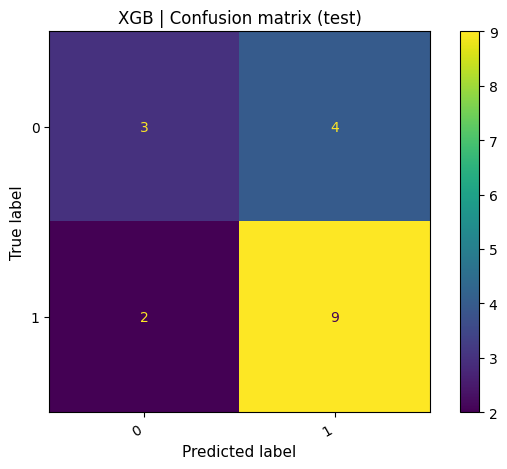

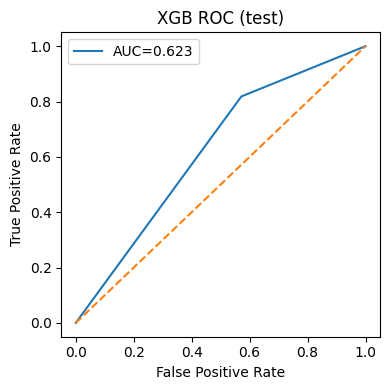

In [30]:
from sklearn.metrics import roc_auc_score
best_pipe = gs.best_estimator_
name='XGB'
y_pred = best_pipe.predict(X_test_new)
mf1 = f1_score(y_test, y_pred, average="macro")

print("\n" + "="*70)
print(name, "TEST macro-F1 =", round(mf1, 4))

plot_confmat(y_test, y_pred, title=f"{name} | Confusion matrix (test)", savepath=None)
plot_roc_if_binary(best_pipe, X_test_new, y_test, title=f"{name} ROC (test)")


In [17]:
import numpy as np
import pandas as pd
import shap

def shap_xgb_multiclass(best_pipe, X_train, X_test, feature_names, class_names):
    """
    best_pipe: fitted sklearn Pipeline with ["imputer", "clf"] where clf is XGBClassifier
    X_train/X_test: raw feature matrices (DataFrame or ndarray)
    feature_names: list of names in correct order
    class_names: e.g. ['Extreme hypoxia','Hypoxia','Normoxia'] in encoder order
    """
    imputer = best_pipe.named_steps["imputer"]
    model   = best_pipe.named_steps["clf"]

    # Apply same preprocessing used in training
    Xtr = imputer.transform(X_train)
    Xte = imputer.transform(X_test)

    # TreeExplainer for XGBoost
    explainer = shap.TreeExplainer(model)

    # Multiclass: SHAP returns list OR array depending on shap version.
    shap_vals = explainer.shap_values(Xte)

    # Normalize output format to: (n_classes, n_samples, n_features)
    if isinstance(shap_vals, list):
        shap_arr = np.stack(shap_vals, axis=0)
    else:
        shap_arr = np.asarray(shap_vals)
    if shap_arr.ndim == 3 and shap_arr.shape[-1] == len(class_names):
        shap_arr = np.transpose(shap_arr, (2, 0, 1))


    # Per-class mean(|SHAP|)
    per_class = {}
    for i, cls in enumerate(class_names):
        per_class[cls] = pd.Series(np.mean(np.abs(shap_arr[i]), axis=0), index=feature_names) \
                            .sort_values(ascending=False)

    if len(class_names) == 2:
        per_class = {
    class_names[1]: pd.Series(np.mean(shap_arr, axis=0), index=feature_names).sort_values(ascending=False),
    class_names[0]: pd.Series(-np.mean(shap_arr, axis=0), index=feature_names).sort_values(ascending=False)
}


    # Overall importance (mean over classes)
    overall = pd.Series(np.mean(np.abs(shap_arr), axis=0), index=feature_names).sort_values(ascending=False)


    return overall, per_class, explainer, shap_arr, Xte


In [18]:
xgb_overall, xgb_per_class, explainer, shap_arr, Xte = shap_xgb_multiclass(
    best_pipe,
    X_train_new,
    X_test_new,
    feature_names=selected_features,
    class_names=["Non_responders","Responders"],
)

print("Top 25 overall SHAP features:")
print(xgb_overall.head(25))

print("\nTop 20 features for each class:")
for cls, s in xgb_per_class.items():
    print("\n", cls)
    print(s.head(20))


Top 25 overall SHAP features:
SLC18A2      0.493881
CDH13        0.339159
GDPD5        0.235668
PRKAG1       0.216579
HADHAP1      0.211433
MYLK3        0.162773
MCTP1        0.162443
SNX6         0.150228
PI15         0.141869
CHI3L1       0.139106
ZNF343       0.119355
KLKB1        0.110182
VPS53        0.104580
SLC2A3       0.094684
RGS3         0.093514
FAM117A      0.088520
B3GAT1       0.074108
PIR          0.071424
CHIA         0.071376
LINC00623    0.071035
FABP2        0.070642
ALDH5A1      0.069872
NKRF         0.059172
TTN          0.058582
EXTL1        0.055946
dtype: float32

Top 20 features for each class:

 Responders
CDH13       0.160842
SNX6        0.080493
HADHAP1     0.072553
CHI3L1      0.033603
VPS53       0.032689
ACTR3B      0.025276
TTN         0.024844
SLC2A3      0.024159
FABP2       0.021496
NKRF        0.020974
ZKSCAN7     0.016723
SPC24       0.016206
SLC6A6      0.016107
TMEM2       0.015300
MGMT        0.015120
KLHL2       0.014350
SLC30A10    0.013443
LZ

In [19]:
import numpy as np
import shap
import matplotlib.pyplot as plt
def plot_shap_results(explainer, shap_arr, Xte, feature_names,
                      class_names=None, plot_type="summary",
                      class_idx=0, sample_idx=None):
    
    shap_arr = np.array(shap_arr)

    # ---- Handle shapes safely ----
    if shap_arr.ndim == 3:
        # (n_classes, n_samples, n_features)
        shap_values = shap_arr[class_idx]
        class_label = class_names[class_idx] if class_names else f"Class {class_idx}"
    elif shap_arr.ndim == 2:
        # (n_samples, n_features) → binary already flattened
        shap_values = shap_arr
        class_label = class_names[1] if class_names and len(class_names)==2 else "Positive Class"
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_arr.shape}")

    print("SHAP values shape used for plotting:", shap_values.shape)

    # ---- Plotting ----
    if plot_type == "summary":
        shap.summary_plot(
            shap_values,
            Xte,
            feature_names=feature_names
        )

    elif plot_type == "bar":

        # For binary case
        if shap_arr.ndim == 3:
            shap_values = shap_arr[0]
        else:
            shap_values = shap_arr

        # Build Explanation object
        explanation = shap.Explanation(
            values=shap_values,
            data=Xte,
            feature_names=feature_names
        )

        clustering = shap.utils.hclust(Xte)

        shap.plots.bar(
            explanation,
            clustering=clustering
        )


    elif plot_type == "force":
        if sample_idx is None:
            raise ValueError("Provide sample_idx for force plot")

        shap.initjs()
        return shap.force_plot(
            explainer.expected_value if shap_arr.ndim == 2 else explainer.expected_value[class_idx],
            shap_values[sample_idx],
            Xte[sample_idx],
            feature_names=feature_names
        )

    else:
        raise ValueError("plot_type must be 'summary', 'bar', or 'force'")


SHAP values shape used for plotting: (18, 2000)


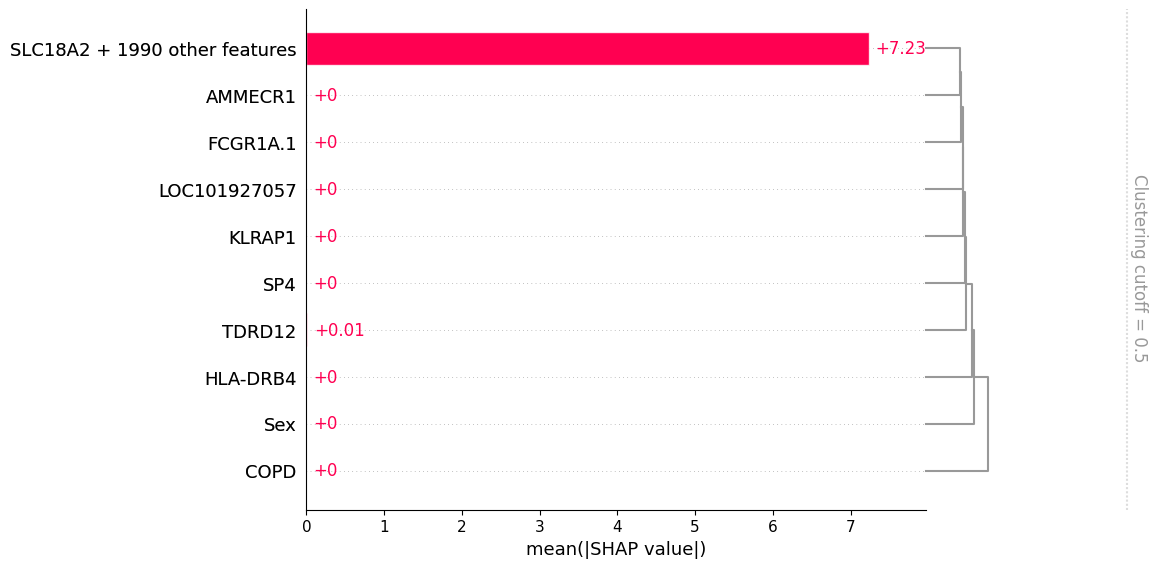

In [20]:
plot_shap_results(explainer, shap_arr, Xte, feature_names=selected_features, class_names=['Non_responders','Responders'], plot_type="bar")


In [21]:
plot_shap_results(
    explainer,
    shap_arr,
    Xte,
    feature_names=selected_features,
    class_names=['Non_responders','Responders'],
    plot_type="force",
    sample_idx=0
)

SHAP values shape used for plotting: (18, 2000)


SHAP values shape used for plotting: (18, 2000)


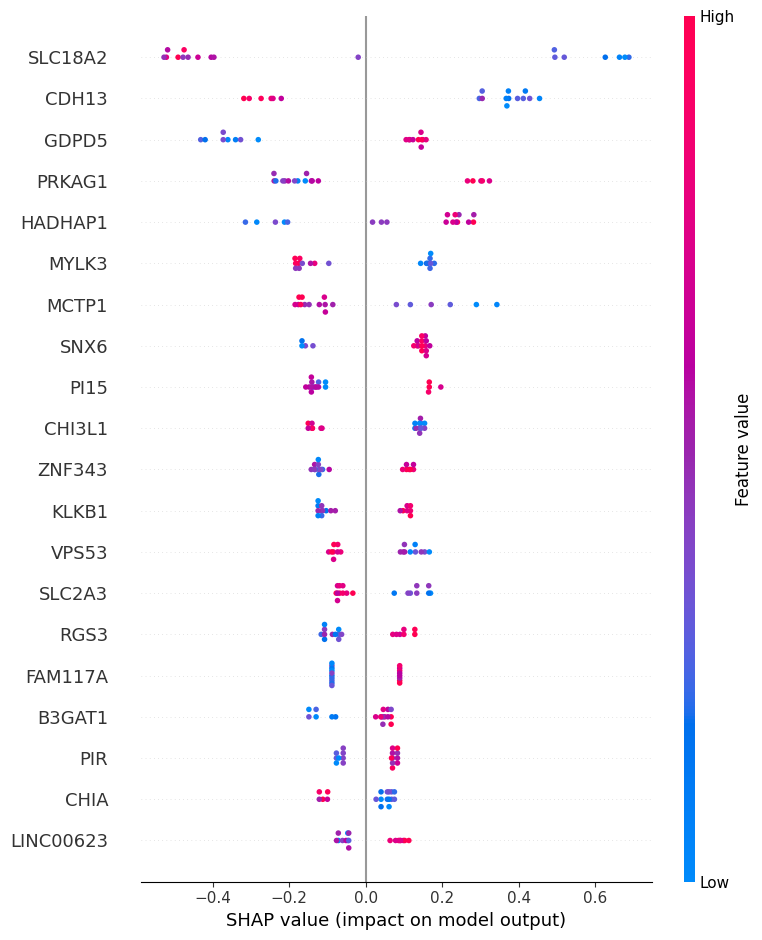

In [22]:
plot_shap_results(explainer, shap_arr, Xte, feature_names=selected_features, class_names=['Non_responders','Responders'], plot_type="summary")